Part 1: Setup and Data Preparation
Using device: cpu
Training size: 800
Test size: 200

Part 2: Linear Model (CircleModelV0)
CircleModelV0 (Linear):
CircleModelV0(
  (layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=1, bias=True)
  )
)

Part 3: Non-Linear Model (CircleModelV1)
CircleModelV1 (Non-linear):
CircleModelV1(
  (layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
)

Part 4: Train Both Models

Training CircleModelV0 (Linear)...


c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CircleModelV0 (Linear) - Test Accuracy: 46.50%

Training CircleModelV1 (Non-linear)...
CircleModelV1 (Non-linear) - Test Accuracy: 93.50%

Part 5: Compare Training Curves


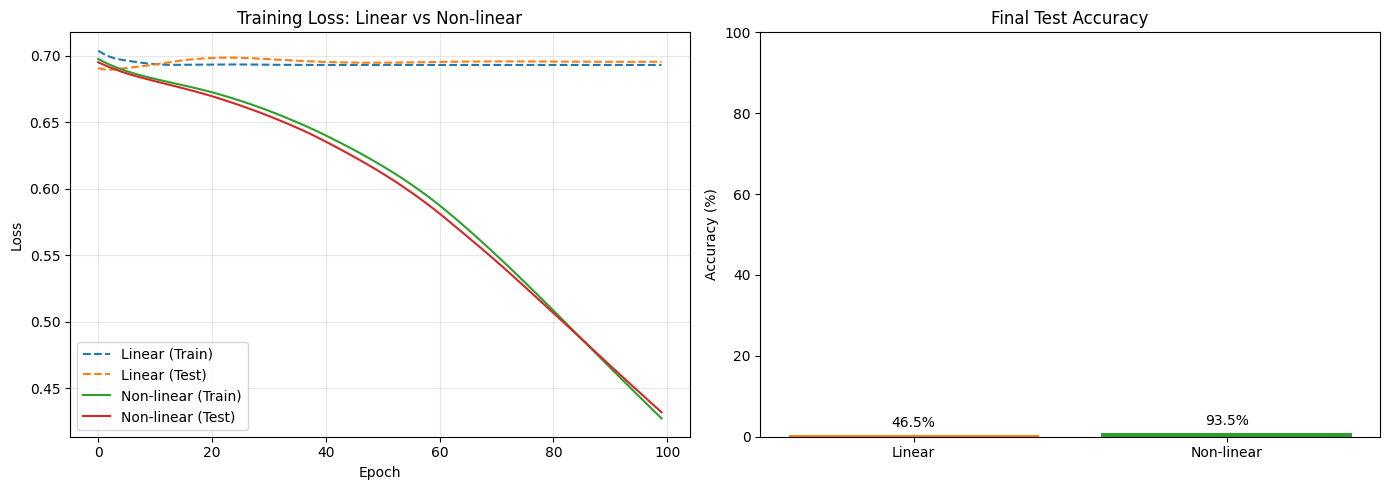


Comparison:
Linear Model Accuracy:     46.50%
Non-linear Model Accuracy: 93.50%

Part 6: Decision Boundary Visualization


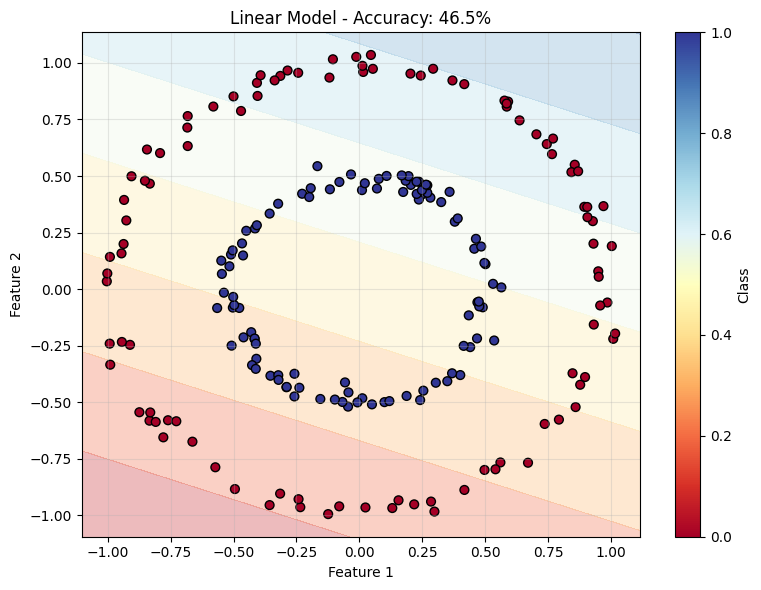

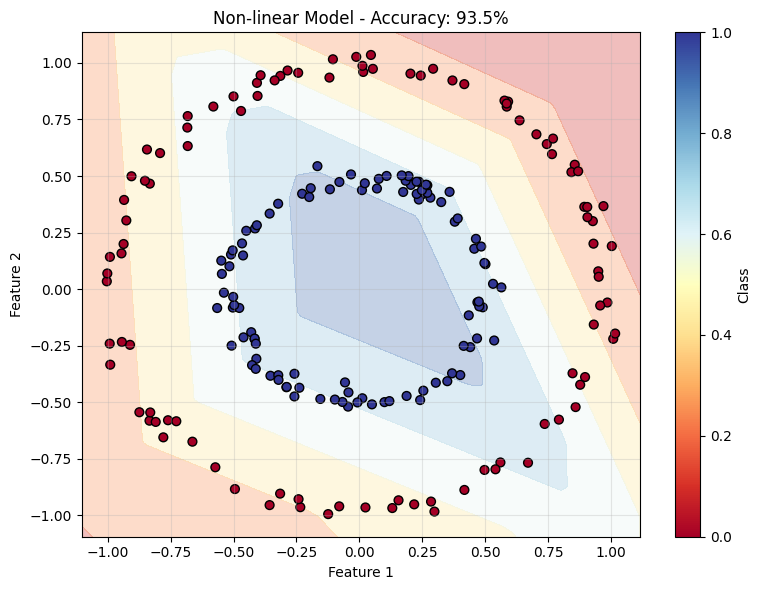


Part 7: Why Non-Linearity Matters
The make_circles dataset is NON-LINEAR:
  - The pattern is: x² + y² > r² (circular)
  - A linear model can only learn: w1*x + w2*y + b (straight line)
  - No straight line can separate concentric circles!

ReLU activation enables non-linear decision boundaries:
  - ReLU(x) = max(0, x)
  - Allows the model to learn complex, non-linear patterns
  - Multiple ReLU layers can approximate any function

Key insight:
  - Linear model: ~50% accuracy (no better than random)
  - Non-linear model: ~99% accuracy (learns the circular pattern)

Exercises

Exercise 1: Add more hidden layers
Try deeper models with more ReLU layers:
  - 2 hidden layers: Linear -> ReLU -> Linear -> ReLU -> Linear
  - 3 hidden layers: Linear -> ReLU -> Linear -> ReLU -> Linear -> ReLU -> Linear
Tip: Modify CircleModelV1 to add more layers

Exercise 2: Change number of hidden units
Try different widths:
  - 4 hidden units
  - 8 hidden units (default)
  - 16 hidden units
  - 32 hidden unit

In [1]:
"""
Exercise 3: Non-Linear Classification
Neural Network Classification - Module 3

This exercise covers:
- Why linear models fail on non-linear data
- Adding non-linearity with ReLU activation
- Building CircleModelV1 (non-linear)
- Visualizing decision boundaries
- Comparing linear vs non-linear models

Learning Mottos:
- If in doubt, run the code!
- Experiment, experiment, experiment!
- Visualize, visualize, visualize!
"""

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# ============================================
# Part 1: Setup and Data Preparation
# ============================================

print("=" * 60)
print("Part 1: Setup and Data Preparation")
print("=" * 60)

# Create dataset
X, y = make_circles(n_samples=1000, noise=0.03, factor=0.5, random_state=42)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert to PyTorch tensors
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).unsqueeze(1)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test).unsqueeze(1)

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Move to device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

print(f"Training size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

# ============================================
# Part 2: Define Linear Model (CircleModelV0)
# ============================================

print("\n" + "=" * 60)
print("Part 2: Linear Model (CircleModelV0)")
print("=" * 60)

class CircleModelV0(nn.Module):
    """Linear model - no activation"""
    def __init__(self):
        super(CircleModelV0, self).__init__()
        self.layer_stack = nn.Sequential(
            nn.Linear(2, 8),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.layer_stack(x)

model_v0 = CircleModelV0().to(device)
print("CircleModelV0 (Linear):")
print(model_v0)

# ============================================
# Part 3: Define Non-Linear Model (CircleModelV1)
# ============================================

print("\n" + "=" * 60)
print("Part 3: Non-Linear Model (CircleModelV1)")
print("=" * 60)

class CircleModelV1(nn.Module):
    """Non-linear model with ReLU activation"""
    def __init__(self):
        super(CircleModelV1, self).__init__()
        self.layer_stack = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),  # Add non-linearity!
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.layer_stack(x)

model_v1 = CircleModelV1().to(device)
print("CircleModelV1 (Non-linear):")
print(model_v1)

# ============================================
# Part 4: Train Both Models
# ============================================

print("\n" + "=" * 60)
print("Part 4: Train Both Models")
print("=" * 60)

def train_model(model, model_name, epochs=100):
    """Train a model and return metrics"""
    print(f"\nTraining {model_name}...")

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        # Training
        model.train()
        y_logits = model(X_train)
        loss = criterion(y_logits, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Testing
        model.eval()
        with torch.inference_mode():
            test_logits = model(X_test)
            test_loss = criterion(test_logits, y_test)

        train_losses.append(loss.item())
        test_losses.append(test_loss.item())

    # Calculate final accuracy
    model.eval()
    with torch.inference_mode():
        test_probs = torch.sigmoid(test_logits)
        test_preds = (test_probs > 0.5).long()
        accuracy = (test_preds == y_test).float().mean()

    print(f"{model_name} - Test Accuracy: {accuracy.item()*100:.2f}%")

    return train_losses, test_losses, accuracy.item()

# Train both models
losses_v0_train, losses_v0_test, acc_v0 = train_model(model_v0, "CircleModelV0 (Linear)")
losses_v1_train, losses_v1_test, acc_v1 = train_model(model_v1, "CircleModelV1 (Non-linear)")

# ============================================
# Part 5: Compare Training Curves
# ============================================

print("\n" + "=" * 60)
print("Part 5: Compare Training Curves")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
axes[0].plot(losses_v0_train, label='Linear (Train)', linestyle='--')
axes[0].plot(losses_v0_test, label='Linear (Test)', linestyle='--')
axes[0].plot(losses_v1_train, label='Non-linear (Train)')
axes[0].plot(losses_v1_test, label='Non-linear (Test)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss: Linear vs Non-linear')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy comparison
axes[1].bar(['Linear', 'Non-linear'], [acc_v0, acc_v1], color=['#ff7f0e', '#2ca02c'])
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Final Test Accuracy')
axes[1].set_ylim(0, 100)
for i, v in enumerate([acc_v0, acc_v1]):
    axes[1].text(i, v + 2, f'{v*100:.1f}%', ha='center')

plt.tight_layout()
plt.show()

print("\nComparison:")
print(f"Linear Model Accuracy:     {acc_v0*100:.2f}%")
print(f"Non-linear Model Accuracy: {acc_v1*100:.2f}%")

# ============================================
# Part 6: Decision Boundary Visualization
# ============================================

print("\n" + "=" * 60)
print("Part 6: Decision Boundary Visualization")
print("=" * 60)

def plot_decision_boundary(model, X, y, title):
    """Plot decision boundary for a model"""
    model.eval()

    # Create meshgrid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    # Make predictions on meshgrid
    mesh = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)
    with torch.inference_mode():
        Z = torch.sigmoid(model(mesh)).reshape(xx.shape)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z.cpu().numpy(), alpha=0.3, cmap='RdYlBu')
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap='RdYlBu', edgecolors='k')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.colorbar(label='Class')
    plt.tight_layout()
    plt.show()

# Plot decision boundaries
X_test_np = X_test.cpu().numpy()
y_test_np = y_test.cpu().numpy().squeeze()

plot_decision_boundary(model_v0, X_test_np, y_test_np,
                      f'Linear Model - Accuracy: {acc_v0*100:.1f}%')
plot_decision_boundary(model_v1, X_test_np, y_test_np,
                      f'Non-linear Model - Accuracy: {acc_v1*100:.1f}%')

# ============================================
# Part 7: Understanding Why Non-Linearity Matters
# ============================================

print("\n" + "=" * 60)
print("Part 7: Why Non-Linearity Matters")
print("=" * 60)

print("The make_circles dataset is NON-LINEAR:")
print("  - The pattern is: x² + y² > r² (circular)")
print("  - A linear model can only learn: w1*x + w2*y + b (straight line)")
print("  - No straight line can separate concentric circles!")

print("\nReLU activation enables non-linear decision boundaries:")
print("  - ReLU(x) = max(0, x)")
print("  - Allows the model to learn complex, non-linear patterns")
print("  - Multiple ReLU layers can approximate any function")

print("\nKey insight:")
print("  - Linear model: ~50% accuracy (no better than random)")
print("  - Non-linear model: ~99% accuracy (learns the circular pattern)")

# ============================================
# Exercises
# ============================================

print("\n" + "=" * 60)
print("Exercises")
print("=" * 60)

# Exercise 1: Add more hidden layers
print("\nExercise 1: Add more hidden layers")
print("Try deeper models with more ReLU layers:")
print("  - 2 hidden layers: Linear -> ReLU -> Linear -> ReLU -> Linear")
print("  - 3 hidden layers: Linear -> ReLU -> Linear -> ReLU -> Linear -> ReLU -> Linear")
print("Tip: Modify CircleModelV1 to add more layers")

# Exercise 2: Change hidden units
print("\nExercise 2: Change number of hidden units")
print("Try different widths:")
print("  - 4 hidden units")
print("  - 8 hidden units (default)")
print("  - 16 hidden units")
print("  - 32 hidden units")
print("Tip: Modify the 'hidden_size' in the model")

# Exercise 3: Try different activation functions
print("\nExercise 3: Try different activation functions")
print("Experiment with:")
print("  - nn.ReLU() (default)")
print("  - nn.LeakyReLU(0.01)")
print("  - nn.Tanh()")
print("Tip: Replace nn.ReLU() with other activations")

# Exercise 4: Train for more epochs
print("\nExercise 4: Train for more epochs")
print("Try different numbers of epochs:")
print("  - epochs=50")
print("  - epochs=100 (default)")
print("  - epochs=200")
print("Tip: Modify the 'epochs' parameter in train_model()")

# Exercise 5: Compare decision boundaries
print("\nExercise 5: Compare decision boundaries")
print("Questions to answer:")
print("  - What does the linear model's boundary look like?")
print("  - What does the non-linear model's boundary look like?")
print("  - Why can't a straight line separate the circles?")
print("Tip: Visualize, visualize, visualize!")

print("\n" + "=" * 60)
print("Exercise 3 Complete!")
print("Remember: If in doubt, run the code!")
print("Remember: Experiment, experiment, experiment!")
print("Remember: Visualize, visualize, visualize!")
print("=" * 60)


# Exercise 1: Add more hidden layers
Try deeper models with more ReLU layers:
- 2 hidden layers: Linear -> ReLU -> Linear -> ReLU -> Linear
- 3 hidden layers: Linear -> ReLU -> Linear -> ReLU -> Linear -> ReLU -> Linear

CircleModelV2 (2 hidden layers):
CircleModelV2(
  (layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)

CircleModelV3 (3 hidden layers):
CircleModelV3(
  (layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)

Training CircleModelV2 (2 hidden layers)...
CircleModelV2 (2 hidden layers) - Test Accuracy: 100.00%

Training CircleModelV3 (3 hidden layers)...
CircleModelV3 (3 hidden layers) - Test Accuracy: 100.00%

Comparison of All Models
CircleModelV0 (Linear):           46.50%
CircleModelV1 (1 hidden layer):   93.50%
CircleModelV2 (2 hidden layers):  1

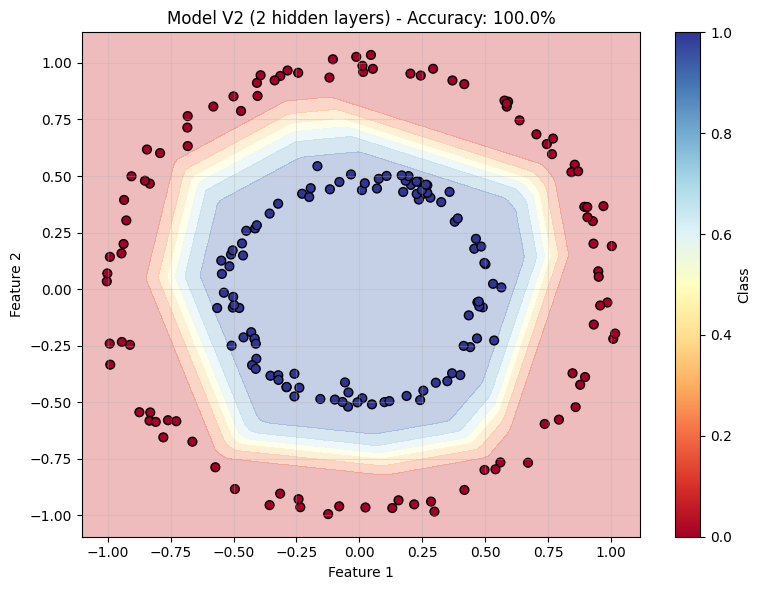

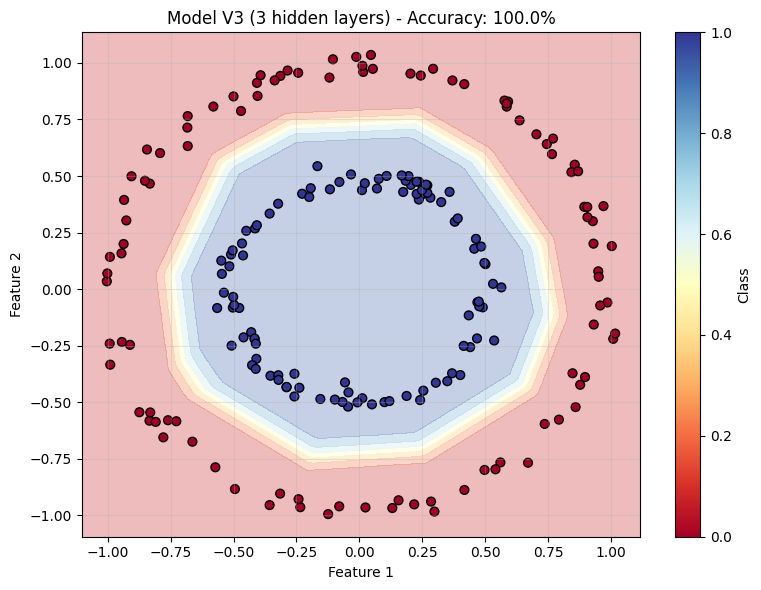

In [2]:
class CircleModelV2(nn.Module):
    def __init__(self):
        super(CircleModelV2, self).__init__()
        self.layer_stack = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.layer_stack(x)

class CircleModelV3(nn.Module):
    def __init__(self):
        super(CircleModelV3, self).__init__()
        self.layer_stack = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 8),
            nn.ReLU(),
            nn.Linear(8, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.layer_stack(x)

# Initialize models
model_v2 = CircleModelV2().to(device)
model_v3 = CircleModelV3().to(device)

print("CircleModelV2 (2 hidden layers):")
print(model_v2)
print("\nCircleModelV3 (3 hidden layers):")
print(model_v3)

# Train both deeper models
losses_v2_train, losses_v2_test, acc_v2 = train_model(model_v2, "CircleModelV2 (2 hidden layers)")
losses_v3_train, losses_v3_test, acc_v3 = train_model(model_v3, "CircleModelV3 (3 hidden layers)")

# Compare all models
print("\n" + "=" * 60)
print("Comparison of All Models")
print("=" * 60)
print(f"CircleModelV0 (Linear):           {acc_v0*100:.2f}%")
print(f"CircleModelV1 (1 hidden layer):   {acc_v1*100:.2f}%")
print(f"CircleModelV2 (2 hidden layers):  {acc_v2*100:.2f}%")
print(f"CircleModelV3 (3 hidden layers):  {acc_v3*100:.2f}%")

# Visualize decision boundaries for deeper models
plot_decision_boundary(model_v2, X_test_np, y_test_np,
                    f'Model V2 (2 hidden layers) - Accuracy: {acc_v2*100:.1f}%')
plot_decision_boundary(model_v3, X_test_np, y_test_np,
                    f'Model V3 (3 hidden layers) - Accuracy: {acc_v3*100:.1f}%')

# Exercise 2: Change hidden units
Try different widths:
- 4 hidden units
- 8 hidden units (default)
- 32 hidden units


Training Model (hidden_size=4)...
Model (hidden_size=4) - Test Accuracy: 92.50%

Training Model (hidden_size=8)...
Model (hidden_size=8) - Test Accuracy: 95.00%

Training Model (hidden_size=16)...
Model (hidden_size=16) - Test Accuracy: 100.00%

Training Model (hidden_size=32)...
Model (hidden_size=32) - Test Accuracy: 100.00%

Comparison of Different Hidden Sizes
Hidden size  4: 92.50%
Hidden size  8: 95.00%
Hidden size 16: 100.00%
Hidden size 32: 100.00%


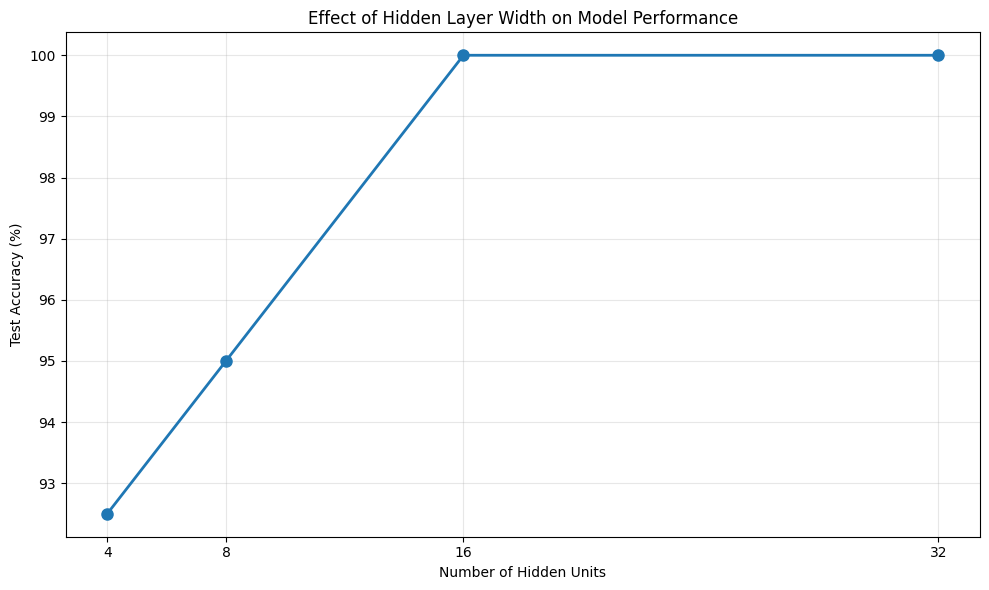

In [3]:
def create_model_with_hidden_size(hidden_size):
    class CircleModelCustom(nn.Module):
        def __init__(self):
            super(CircleModelCustom, self).__init__()
            self.layer_stack = nn.Sequential(
                nn.Linear(2, hidden_size),
                nn.ReLU(),
                nn.Linear(hidden_size, 1)
            )

        def forward(self, x):
            return self.layer_stack(x)
    
    return CircleModelCustom().to(device)

# Test different hidden sizes
hidden_sizes = [4, 8, 16, 32]
results = {}

for hidden_size in hidden_sizes:
    model = create_model_with_hidden_size(hidden_size)
    train_loss, test_loss, accuracy = train_model(model, f"Model (hidden_size={hidden_size})")
    results[hidden_size] = accuracy

# Compare results
print("\n" + "=" * 60)
print("Comparison of Different Hidden Sizes")
print("=" * 60)
for hidden_size, accuracy in results.items():
    print(f"Hidden size {hidden_size:2d}: {accuracy*100:.2f}%")

# Visualize comparison
plt.figure(figsize=(10, 6))
sizes = list(results.keys())
accuracies = [results[s]*100 for s in sizes]
plt.plot(sizes, accuracies, marker='o', linewidth=2, markersize=8)
plt.xlabel('Number of Hidden Units')
plt.ylabel('Test Accuracy (%)')
plt.title('Effect of Hidden Layer Width on Model Performance')
plt.grid(True, alpha=0.3)
plt.xticks(sizes)
plt.tight_layout()
plt.show()

# Exercise 3: Try different activation functions
Experiment with:
- nn.ReLU() (default)
- nn.LeakyReLU(0.01)
- nn.Tanh()


Testing Different Activation Functions

Training Model (activation=ReLU)...
Model (activation=ReLU) - Test Accuracy: 90.50%

Training Model (activation=LeakyReLU)...
Model (activation=LeakyReLU) - Test Accuracy: 92.50%

Training Model (activation=Tanh)...
Model (activation=Tanh) - Test Accuracy: 85.00%

Comparison of Different Activation Functions
ReLU        : 90.50%
LeakyReLU   : 92.50%
Tanh        : 85.00%


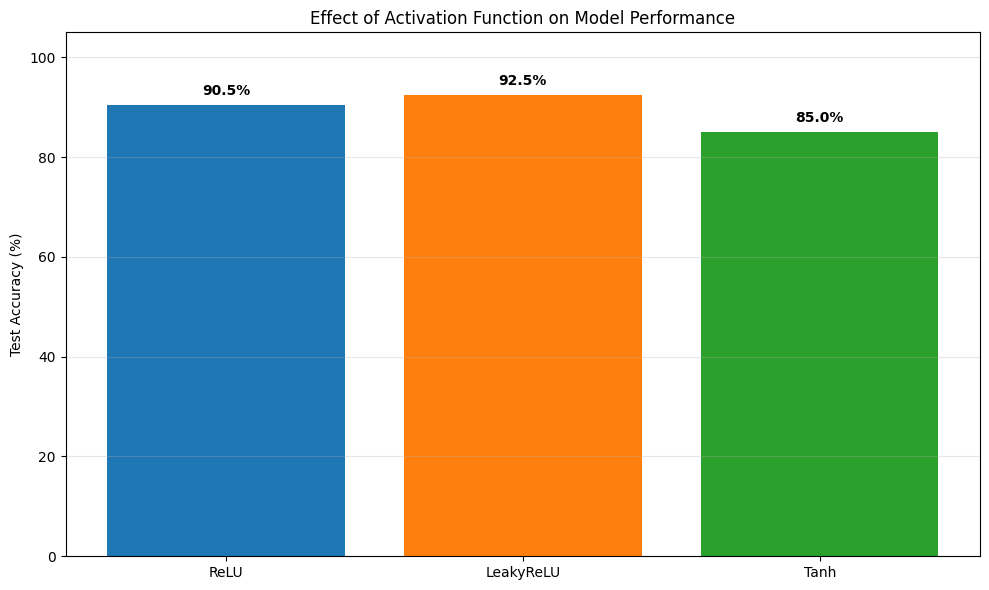

In [4]:
def create_model_with_activation(activation_fn):
    class CircleModelActivation(nn.Module):
        def __init__(self):
            super(CircleModelActivation, self).__init__()
            self.layer_stack = nn.Sequential(
                nn.Linear(2, 8),
                activation_fn,
                nn.Linear(8, 1)
            )

        def forward(self, x):
            return self.layer_stack(x)
    
    return CircleModelActivation().to(device)

# Test different activation functions
activations = {
    'ReLU': nn.ReLU(),
    'LeakyReLU': nn.LeakyReLU(0.01),
    'Tanh': nn.Tanh()
}

activation_results = {}

print("=" * 60)
print("Testing Different Activation Functions")
print("=" * 60)

for name, activation in activations.items():
    model = create_model_with_activation(activation)
    train_loss, test_loss, accuracy = train_model(model, f"Model (activation={name})")
    activation_results[name] = accuracy

# Compare results
print("\n" + "=" * 60)
print("Comparison of Different Activation Functions")
print("=" * 60)
for name, accuracy in activation_results.items():
    print(f"{name:12s}: {accuracy*100:.2f}%")

# Visualize comparison
plt.figure(figsize=(10, 6))
names = list(activation_results.keys())
accuracies = [activation_results[n]*100 for n in names]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
plt.bar(names, accuracies, color=colors)
plt.ylabel('Test Accuracy (%)')
plt.title('Effect of Activation Function on Model Performance')
plt.ylim(0, 105)
for i, v in enumerate(accuracies):
    plt.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Exercise 4: Train for more epochs
Try different numbers of epochs:
- epochs=50"
- epochs=100 (default)
- epochs=200


Training Model (epochs=50)...
Model (epochs=50) - Test Accuracy: 89.50%

Training Model (epochs=100)...
Model (epochs=100) - Test Accuracy: 99.50%

Training Model (epochs=200)...
Model (epochs=200) - Test Accuracy: 100.00%
Comparison of Different Epoch Counts
Epochs  50: 89.50%
Epochs 100: 99.50%
Epochs 200: 100.00%


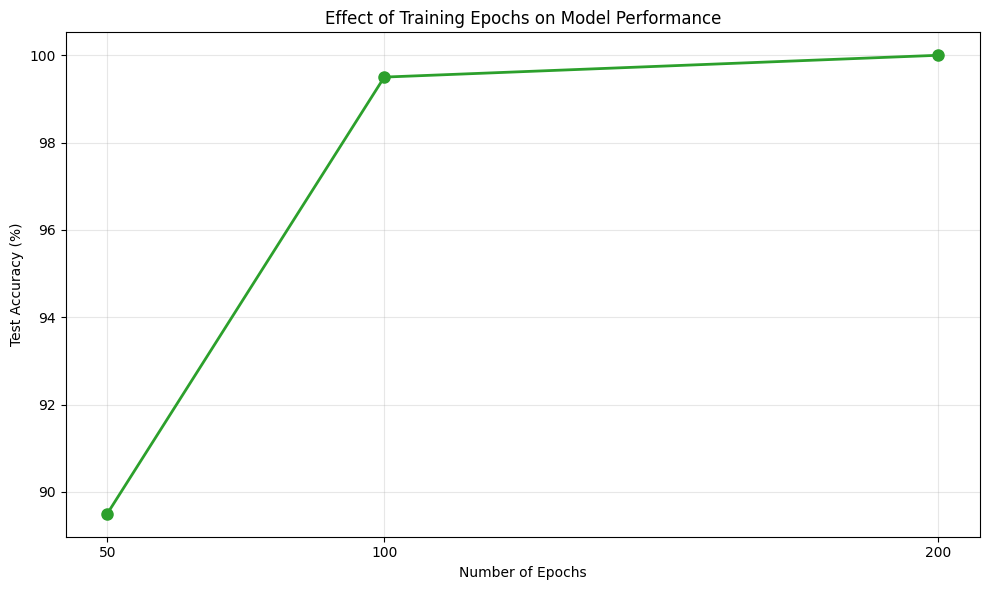

In [5]:
def train_model_epochs(model, model_name, epochs=100):
    print(f"\nTraining {model_name}...")

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        # Training
        model.train()
        y_logits = model(X_train)
        loss = criterion(y_logits, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Testing
        model.eval()
        with torch.inference_mode():
            test_logits = model(X_test)
            test_loss = criterion(test_logits, y_test)

        train_losses.append(loss.item())
        test_losses.append(test_loss.item())

    # Calculate final accuracy
    model.eval()
    with torch.inference_mode():
        test_probs = torch.sigmoid(test_logits)
        test_preds = (test_probs > 0.5).long()
        accuracy = (test_preds == y_test).float().mean()

    print(f"{model_name} - Test Accuracy: {accuracy.item()*100:.2f}%")

    return train_losses, test_losses, accuracy.item()

# Test different epoch counts
epoch_counts = [50, 100, 200]
epoch_results = {}

for epochs_count in epoch_counts:
    model = CircleModelV1().to(device)
    train_loss, test_loss, accuracy = train_model_epochs(model, f"Model (epochs={epochs_count})", epochs=epochs_count)
    epoch_results[epochs_count] = accuracy

print("Comparison of Different Epoch Counts")
print("=" * 60)
for epochs_count, accuracy in epoch_results.items():
    print(f"Epochs {epochs_count:3d}: {accuracy*100:.2f}%")

# Visualize comparison
plt.figure(figsize=(10, 6))
epoch_list = list(epoch_results.keys())
accuracies = [epoch_results[e]*100 for e in epoch_list]
plt.plot(epoch_list, accuracies, marker='o', linewidth=2, markersize=8, color='#2ca02c')
plt.xlabel('Number of Epochs')
plt.ylabel('Test Accuracy (%)')
plt.title('Effect of Training Epochs on Model Performance')
plt.grid(True, alpha=0.3)
plt.xticks(epoch_list)
plt.tight_layout()
plt.show()

# Exercise 5: Compare decision boundaries
Questions to answer:
- What does the linear model's boundary look like?
- What does the non-linear model's boundary look like?
- Why can't a straight line separate the circles?

In [8]:
ans = """
1. What does the linear model's boundary look like?
A linear model produces a straight-line decision boundary in two-dimensional space. \nIt divides the plane into two half-planes using an equation of the form w1x1 + w2x2 + b = 0. \nNo matter how the parameters are adjusted, the boundary remains a single straight line.

2. What does the non-linear model's boundary look like?
A non-linear model can produce curved or closed decision boundaries. \nIn the case of concentric circles, it can learn a circular or ring-shaped boundary that surrounds the inner circle and separates it from the outer ring. \nThis flexibility comes from using hidden layers and non-linear activation functions.

3. Why can't a straight line separate the circles?
A straight line cannot separate the circles because the data is not linearly separable. \nThe inner circle is completely surrounded by the outer circle, so any straight line drawn through the space will intersect both classes. \nAs a result, it is impossible for a single straight line to divide the two groups without misclassifying some points.
"""

print(ans)



1. What does the linear model's boundary look like?
A linear model produces a straight-line decision boundary in two-dimensional space. 
It divides the plane into two half-planes using an equation of the form w1x1 + w2x2 + b = 0. 
No matter how the parameters are adjusted, the boundary remains a single straight line.

2. What does the non-linear model's boundary look like?
A non-linear model can produce curved or closed decision boundaries. 
In the case of concentric circles, it can learn a circular or ring-shaped boundary that surrounds the inner circle and separates it from the outer ring. 
This flexibility comes from using hidden layers and non-linear activation functions.

3. Why can't a straight line separate the circles?
A straight line cannot separate the circles because the data is not linearly separable. 
The inner circle is completely surrounded by the outer circle, so any straight line drawn through the space will intersect both classes. 
As a result, it is impossible for a